# Моделирование работы службы такси

## Введение

Данный проект представляет собой симуляцию работы службы такси с использованием дискретно-событийного моделирования. Целью является анализ эффективности работы такси, включая время поиска пассажиров и время в пути. Симуляция позволяет настроить количество такси, длительность моделирования и другие параметры для изучения их влияния на общую производительность системы.

Модель отслеживает следующие ключевые метрики для каждого такси:
* **Количество поездок**: Общее число выполненных поездок.
    * **Время с пассажиром**: Суммарное время, проведенное такси в поездках с пассажирами.
    * **Время поиска**: Суммарное время, которое такси тратит на поиск пассажира.

Визуализация событий на графиках помогает наглядно представить динамику работы каждого такси и общую загруженность системы.


In [1]:
!pip install matplotlib numpy

## Импорт библиотек и константы

В этом разделе импортируются необходимые библиотеки и определяются глобальные константы, используемые в симуляции.

* `random`: Для генерации случайных чисел, имитирующих случайные задержки.
* `collections`: Используется `namedtuple` для создания типизированных событий и `defaultdict` для удобного сбора статистики по такси.
* `queue`: Используется `PriorityQueue` для управления очередью событий, гарантируя их обработку в хронологическом порядке.
* `matplotlib.pyplot`: Для построения графиков и визуализации результатов симуляции.
* `numpy`: Для работы с массивами и математическими операциями, может пригодиться для более сложных статистических расчетов или генерации данных.


In [2]:
import random, collections, queue
import matplotlib.pyplot as plt
import numpy as np

# --- Глобальные константы симуляции ---
DEFAULT_NUMBER_OF_TAXIS = 7  # Количество такси по умолчанию
DEFAULT_END_TIME = 300       # Время окончания симуляции по умолчанию
SEARCH_DURATION = 5          # Средняя продолжительность поиска пассажира
TRIP_DURATION = 20           # Средняя продолжительность поездки с пассажиром
DEPARTURE_INTERVAL = 5       # Интервал между выездом такси из гаража
DURATION_VARIATION = 4       # Максимальное отклонение от среднего времени для действий

# Определение структуры события с полями 'время', 'ID' такси и 'состояние'
Event = collections.namedtuple('Event', 'time ID state')
eventslog = [] # Глобальный список для хранения всех событий симуляции

# Словарь для сбора статистики по каждому такси. Использует defaultdict,
# чтобы автоматически инициализировать статистику для нового ID такси.
taxi_stats = collections.defaultdict(lambda: {
    'trips': 0,
    'trip_duration': 0,
    'search_duration': 0,
    'last_search_start': None, # Время начала последнего поиска (для расчета длительности поиска)
    'idle_duration': 0,        # Время простоя (не используется в текущей модели, но может быть полезно)
    'last_state_change_time': 0 # Время последнего изменения состояния для расчета простоя/занятости
})

## Процесс такси (`taxi_process`)

Функция `taxi_process` является генератором и моделирует поведение одного такси в симуляции. Каждое такси представлено экземпляром этого генератора.

* **`ident`**: Уникальный идентификатор такси.
* **`trips`**: Количество поездок, которое должно совершить такси.
* **`start_time`**: Время, когда такси начинает свою работу.

Логика работы такси:
1.  **Выезд из гаража**: Такси появляется в симуляции в `start_time`.
2.  **Цикл поездок**: Такси совершает заданное количество поездок.
    * **Начало поиска пассажира**: Фиксируется время начала поиска.
    * **Посадка пассажира**: Генератор 

In [3]:
def taxi_process(ident, trips, start_time=0):
    """Моделирует поведение одного такси."""
    # Такси выезжает из гаража в заданное start_time
    time = yield Event(start_time, ident, 'выехал из гаража')
    taxi_stats[ident]['last_state_change_time'] = time # Обновляем время изменения состояния

    for i in range(trips):
        # Расчет времени простоя перед началом поиска
        if taxi_stats[ident]['last_state_change_time'] is not None:
            idle_time = time - taxi_stats[ident]['last_state_change_time']
            taxi_stats[ident]['idle_duration'] += idle_time

        # Начало поиска пассажира
        taxi_stats[ident]['last_search_start'] = time # Фиксируем время начала поиска
        time = yield Event(time, ident, 'поиск пассажира') # Событие поиска
        taxi_stats[ident]['last_state_change_time'] = time # Обновляем время изменения состояния

        # Посадка пассажира
        # Расчет времени поиска
        if taxi_stats[ident]['last_search_start'] is not None:
            search_time = time - taxi_stats[ident]['last_search_start']
            taxi_stats[ident]['search_duration'] += search_time
            taxi_stats[ident]['last_search_start'] = None # Сбрасываем флаг поиска
        
        time = yield Event(time, ident, 'посадил пассажира')
        taxi_stats[ident]['last_state_change_time'] = time # Обновляем время изменения состояния

        # Высадка пассажира
        # Здесь можно было бы добавить отдельное событие 'в пути' для более детального анализа
        trip_start_time = time # Сохраняем время начала поездки
        time = yield Event(time, ident, 'высадил пассажира')
        
        # Расчет времени поездки
        trip_time = time - trip_start_time
        taxi_stats[ident]['trip_duration'] += trip_time
        taxi_stats[ident]['trips'] += 1 # Увеличиваем счетчик поездок
        taxi_stats[ident]['last_state_change_time'] = time # Обновляем время изменения состояния

    # Возвращение в гараж после выполнения всех поездок
    yield Event(time, ident, 'уехал в гараж')
    taxi_stats[ident]['last_state_change_time'] = time # Обновляем время изменения состояния

    # Вывод финальной статистики по такси в конце его работы
    print(f"Такси {ident}: поездок={taxi_stats[ident]['trips']}, "
          f"время с пассажиром={taxi_stats[ident]['trip_duration']:.2f}, "
          f"время поиска={taxi_stats[ident]['search_duration']:.2f}, "
          f"время простоя={taxi_stats[ident]['idle_duration']:.2f}")


## Симулятор (`Simulator`)

Класс `Simulator` управляет ходом дискретно-событийной симуляции. Он отвечает за планирование и выполнение событий в правильном хронологическом порядке.

* **`__init__(self, procs_map)`**: Конструктор инициализирует симулятор.
    * `self.events`: `PriorityQueue` для хранения будущих событий. События автоматически сортируются по времени.
    * `self.procs`: Словарь, сопоставляющий ID такси с их генераторами (`taxi_process`).
    * `self.msglist`: Список для сбора логов симуляции.

* **`run(self, end_time)`**: Основной метод для запуска симуляции до `end_time`.
    * **Инициализация событий**: В начале симуляции из каждого генератора такси извлекается первое событие (выезд из гаража) и добавляется в очередь событий.
    * **Главный цикл симуляции**: Продолжается до тех пор, пока `sim_time` не достигнет `end_time` или очередь событий не опустеет.
        * Извлекается **текущее событие** с наименьшим временем из очереди.
        * Обновляется **`sim_time`** до времени текущего события.
        * Логируется текущее событие.
        * Определяется **длительность** следующего действия на основе `previous_action`.
        * Вычисляется **`next_time`** - время, когда произойдет следующее событие для данного такси.
        * **`active_proc.send(next_time)`**: Генератору такси отправляется `next_time`, и он возвращает следующее событие.
        * Если генератор завершает работу (`StopIteration`), такси удаляется из списка активных процессов.
        * Иначе, следующее событие добавляется обратно в очередь.

* **`msg2list(self, msgstring)`**: Вспомогательный метод для добавления сообщений в лог симуляции.

In [4]:
class Simulator:
    """Управляет ходом дискретно-событийной симуляции."""
    global eventslog # Доступ к глобальному списку событий

    def __init__(self, procs_map):
        self.events = queue.PriorityQueue() # Очередь событий (приоритет по времени)
        self.procs = dict(procs_map)      # Словарь {ID такси: генератор такси}
        self.msglist = []                 # Список для хранения логов симуляции

    def run(self, end_time):
        """Запускает симуляцию до заданного end_time."""
        # Инициализация: получаем первое событие от каждого такси и добавляем в очередь
        for _, proc in sorted(self.procs.items()):
            try:
                first_event = next(proc) # Получаем первое событие (выезд из гаража)
                self.events.put(first_event)
                eventslog.append(first_event)
            except StopIteration: # Если процесс сразу завершился
                pass 

        sim_time = 0 # Текущее время симуляции
        while sim_time < end_time:
            if self.events.empty():
                self.msg2list(f'***События закончились! Время={sim_time}***')
                break

            current_event = self.events.get() # Извлекаем следующее событие
            sim_time, proc_id, previous_action = current_event.time, current_event.ID, current_event.state
            self.msg2list(f'{proc_id}: {sim_time:>3d} >> {previous_action}') # Логируем событие

            active_proc = self.procs.get(proc_id) # Получаем генератор такси
            if not active_proc: # Если такси уже завершило работу
                continue
            
            # Вычисляем длительность текущего действия и время следующего события
            duration = compute_duration(previous_action)
            next_time = sim_time + duration

            try:
                # Отправляем новое время генератору и получаем следующее событие
                next_event = active_proc.send(next_time)
            except StopIteration: # Если генератор завершил свою работу
                del self.procs[proc_id] # Удаляем такси из активных процессов
            else:
                # Добавляем следующее событие в очередь и в лог событий
                self.events.put(next_event)
                eventslog.append(next_event)
        else:
            # Сообщение, если время симуляции истекло
            msg = '*** Время симуляции истекло: {} событий осталось ***'
            self.msg2list(msg.format(self.events.qsize()))

    def msg2list(self, msgstring):
        """Добавляет сообщение в список логов симуляции."""
        self.msglist.append(msgstring)


## Расчет длительности действий (`compute_duration`)

Функция `compute_duration` определяет продолжительность каждого действия такси, добавляя случайное отклонение для придания реалистичности симуляции.

* `previous_action`: Строка, описывающая последнее выполненное действие.

Продолжительность:
* **`'выехал из гаража'` или `'высадил пассажира'`**: Эти действия приводят к началу поиска, поэтому их длительность равна `SEARCH_DURATION`.
* **`'посадил пассажира'`**: Это действие означает начало поездки, поэтому длительность равна `TRIP_DURATION`.
    * **`'поиск пассажира'`**: Длительность также равна `SEARCH_DURATION`.
* **`'уехал в гараж'`**: Длительность возвращения в гараж фиксирована (например, 4 единицы времени).
    * **Случайное отклонение**: `random.uniform(interval - DURATION_VARIATION, interval + DURATION_VARIATION)` добавляет случайность, делая симуляцию менее детерминированной.

In [5]:
def compute_duration(previous_action):
    """Вычисляет продолжительность действия со случайным отклонением."""
    if previous_action in ['выехал из гаража', 'высадил пассажира', 'поиск пассажира']:
        interval = SEARCH_DURATION
    elif previous_action == 'посадил пассажира':
        interval = TRIP_DURATION
    elif previous_action == 'уехал в гараж':
        interval = 4  # Фиксированное время возвращения в гараж
    else:
        raise ValueError('Неизвестное действие: ' + str(previous_action))
    
    # Добавляем случайное отклонение для реалистичности
    return int(random.uniform(interval - DURATION_VARIATION, interval + DURATION_VARIATION))


## Основная функция симуляции (`main`)

Функция `main` настраивает и запускает симуляцию, а затем обрабатывает и визуализирует результаты.

* **Параметры**: `end_time`, `num_taxis`, `seed` (для воспроизводимости).
    * **Инициализация такси**: Создает словарь генераторов такси. Каждое такси имеет свой `ID`, количество поездок (от 3 до 9) и время выезда из гаража, зависящее от `DEPARTURE_INTERVAL`.
    * **Запуск симуляции**: Создает экземпляр `Simulator` и вызывает его метод `run()`.
    * **Логирование**: Выводит отсортированный лог всех событий симуляции.
    * **Визуализация**: Создает несколько графиков для анализа результатов:
        * **График работы такси (точечный)**: Отображает события (начало/конец поездки, гараж) для каждого такси по времени, используя разные маркеры и цвета.
        * **Гистограмма количества поездок**: Показывает распределение числа поездок, выполненных каждым такси.
        * **Гистограмма времени поиска и времени поездок**: Отображает суммарное время поиска и время с пассажиром для каждого такси.
        * **Сводная статистика**: Выводит общие агрегированные метрики для всех такси.

Используются улучшенные стили `matplotlib` для более привлекательного вида графиков.

In [6]:
def main(end_time=DEFAULT_END_TIME, num_taxis=DEFAULT_NUMBER_OF_TAXIS, seed=None):
    """Основная функция для настройки, запуска и визуализации симуляции."""
    global eventslog # Доступ к глобальному списку событий
    global taxi_stats # Доступ к глобальной статистике такси
    
    if seed is not None:
        random.seed(seed) # Устанавливаем seed для воспроизводимости результатов
    
    # Сброс статистики и логов перед каждым новым запуском симуляции
    eventslog = []
    taxi_stats.clear()

    # Инициализация такси: каждое такси имеет уникальный ID, случайное количество поездок 
    # (от 3 до 9) и время выезда из гаража, зависящее от DEPARTURE_INTERVAL.
    taxis = {i: taxi_process(i, random.randint(3, 9), i * DEPARTURE_INTERVAL)
             for i in range(num_taxis)}
    
    sim = Simulator(taxis) # Создаем экземпляр симулятора
    sim.run(end_time)      # Запускаем симуляцию

    # Сортируем и выводим лог событий симуляции
    print("\n--- Лог симуляции ---")
    sim.msglist.sort()
    for m in sim.msglist:
        print(m)
    print("---------------------")

    # --- Визуализация результатов ---

    # Улучшение стилей графиков
    plt.style.use('seaborn-v0_8-darkgrid') # Использование стиля seaborn
    # plt.rcParams['font.family'] = 'DejaVu Sans' # Установка шрифта, если нужно
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['legend.fontsize'] = 10

    # График 1: Активность такси по времени
    plt.figure(figsize=(14, 8))
    
    # Разделяем события на разные типы для различных маркеров и цветов
    pickup = [e for e in eventslog if e.state == 'посадил пассажира']
    dropoff = [e for e in eventslog if e.state == 'высадил пассажира']
    search = [e for e in eventslog if e.state == 'поиск пассажира']
    garage_in_out = [e for e in eventslog if e.state in ['выехал из гаража', 'уехал в гараж']]
    
    plt.scatter([e.time for e in pickup], [e.ID for e in pickup], 
                c='forestgreen', marker='^', s=150, label='Начало поездки', alpha=0.8)
    plt.scatter([e.time for e in dropoff], [e.ID for e in dropoff], 
                c='firebrick', marker='v', s=150, label='Конец поездки', alpha=0.8)
    plt.scatter([e.time for e in search], [e.ID for e in search], 
                c='orange', marker='X', s=100, label='Поиск пассажира', alpha=0.7)
    plt.scatter([e.time for e in garage_in_out], [e.ID for e in garage_in_out], 
                c='royalblue', marker='s', s=80, label='Гараж (въезд/выезд)', alpha=0.7)
    
    plt.xlabel("Время симуляции", fontsize=12)
    plt.ylabel("ID Такси", fontsize=12)
    plt.title(f"Активность такси во времени (Количество такси: {num_taxis})", fontsize=14)
    plt.yticks(range(num_taxis)) # Установка меток для каждого такси
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # График 2: Гистограмма количества поездок по такси
    plt.figure(figsize=(10, 6))
    taxi_ids = sorted(taxi_stats.keys())
    trips_count = [taxi_stats[tid]['trips'] for tid in taxi_ids]

    plt.bar(taxi_ids, trips_count, color='teal', alpha=0.8)
    plt.xlabel("ID Такси", fontsize=12)
    plt.ylabel("Количество поездок", fontsize=12)
    plt.title(f"Количество поездок, выполненных каждым такси (Всего такси: {num_taxis})", fontsize=14)
    plt.xticks(taxi_ids) # Установка меток для каждого такси
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # График 3: Сравнение времени поиска, времени с пассажиром и простоя
    plt.figure(figsize=(14, 7))
    search_times = [taxi_stats[tid]['search_duration'] for tid in taxi_ids]
    trip_times = [taxi_stats[tid]['trip_duration'] for tid in taxi_ids]
    idle_times = [taxi_stats[tid]['idle_duration'] for tid in taxi_ids]

    bar_width = 0.25
    r1 = np.arange(len(taxi_ids))
    r2 = [x + bar_width for x in r1]
    r3 = [x + bar_width * 2 for x in r1]

    plt.bar(r1, search_times, color='orange', width=bar_width, edgecolor='grey', label='Время поиска')
    plt.bar(r2, trip_times, color='lightgreen', width=bar_width, edgecolor='grey', label='Время с пассажиром')
    plt.bar(r3, idle_times, color='skyblue', width=bar_width, edgecolor='grey', label='Время простоя')

    plt.xlabel("ID Такси", fontsize=12)
    plt.ylabel("Время (единицы)", fontsize=12)
    plt.title(f"Сравнение времени по типам активности для каждого такси (Всего такси: {num_taxis})", fontsize=14)
    plt.xticks([r + bar_width for r in range(len(taxi_ids))], taxi_ids)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Сводная статистика
    total_trips = sum(ts['trips'] for ts in taxi_stats.values())
    total_trip_duration = sum(ts['trip_duration'] for ts in taxi_stats.values())
    total_search_duration = sum(ts['search_duration'] for ts in taxi_stats.values())
    total_idle_duration = sum(ts['idle_duration'] for ts in taxi_stats.values())

    print("\n--- Сводная статистика симуляции ---")
    print(f"Общее количество выполненных поездок: {total_trips}")
    print(f"Общее время с пассажиром: {total_trip_duration:.2f}")
    print(f"Общее время поиска пассажиров: {total_search_duration:.2f}")
    print(f"Общее время простоя такси: {total_idle_duration:.2f}")
    
    if total_trips > 0:
        avg_trip_duration = total_trip_duration / total_trips
        print(f"Среднее время одной поездки: {avg_trip_duration:.2f}")
    
    # Среднее время поиска на такси
    if num_taxis > 0:
        avg_search_per_taxi = total_search_duration / num_taxis
        print(f"Среднее время поиска на одно такси: {avg_search_per_taxi:.2f}")
    print("-------------------------------------")


## Запуск симуляции с различными параметрами

Здесь симуляция запускается несколько раз с разными конфигурациями для демонстрации гибкости модели и анализа влияния различных параметров:

* **Вариант 1**: 5 такси, `end_time=300`, `seed=42`. Используется для базовой оценки производительности с меньшим количеством такси.
* **Вариант 2**: 7 такси, `end_time=300`, `seed=123`. Стандартное количество такси, но с другим `seed` для демонстрации различий в случайных результатах.
    * **Вариант 3**: 9 такси, `end_time=300`, `seed=42`. Увеличение количества такси для оценки влияния на загруженность и время ожидания.

=== Вариант 1: 5 такси ===
Такси 1: поездок=3, время с пассажиром=5.00, время поиска=15.00, время простоя=0.00
Такси 2: поездок=3, время с пассажиром=11.00, время поиска=9.00, время простоя=0.00
Такси 4: поездок=5, время с пассажиром=28.00, время поиска=17.00, время простоя=0.00
Такси 0: поездок=8, время с пассажиром=41.00, время поиска=27.00, время простоя=0.00
Такси 3: поездок=8, время с пассажиром=24.00, время поиска=40.00, время простоя=0.00

--- Лог симуляции ---
***События закончились! Время=236***
0:   0 >> выехал из гаража
0:   2 >> поиск пассажира
0:   4 >> посадил пассажира
0:  20 >> высадил пассажира
0:  26 >> поиск пассажира
0:  30 >> посадил пассажира
0:  52 >> высадил пассажира
0:  53 >> поиск пассажира
0:  57 >> посадил пассажира
0:  75 >> высадил пассажира
0:  82 >> поиск пассажира
0:  86 >> посадил пассажира
0: 108 >> высадил пассажира
0: 110 >> поиск пассажира
0: 114 >> посадил пассажира
0: 135 >> высадил пассажира
0: 142 >> поиск пассажира
0: 146 >> посадил пассажира

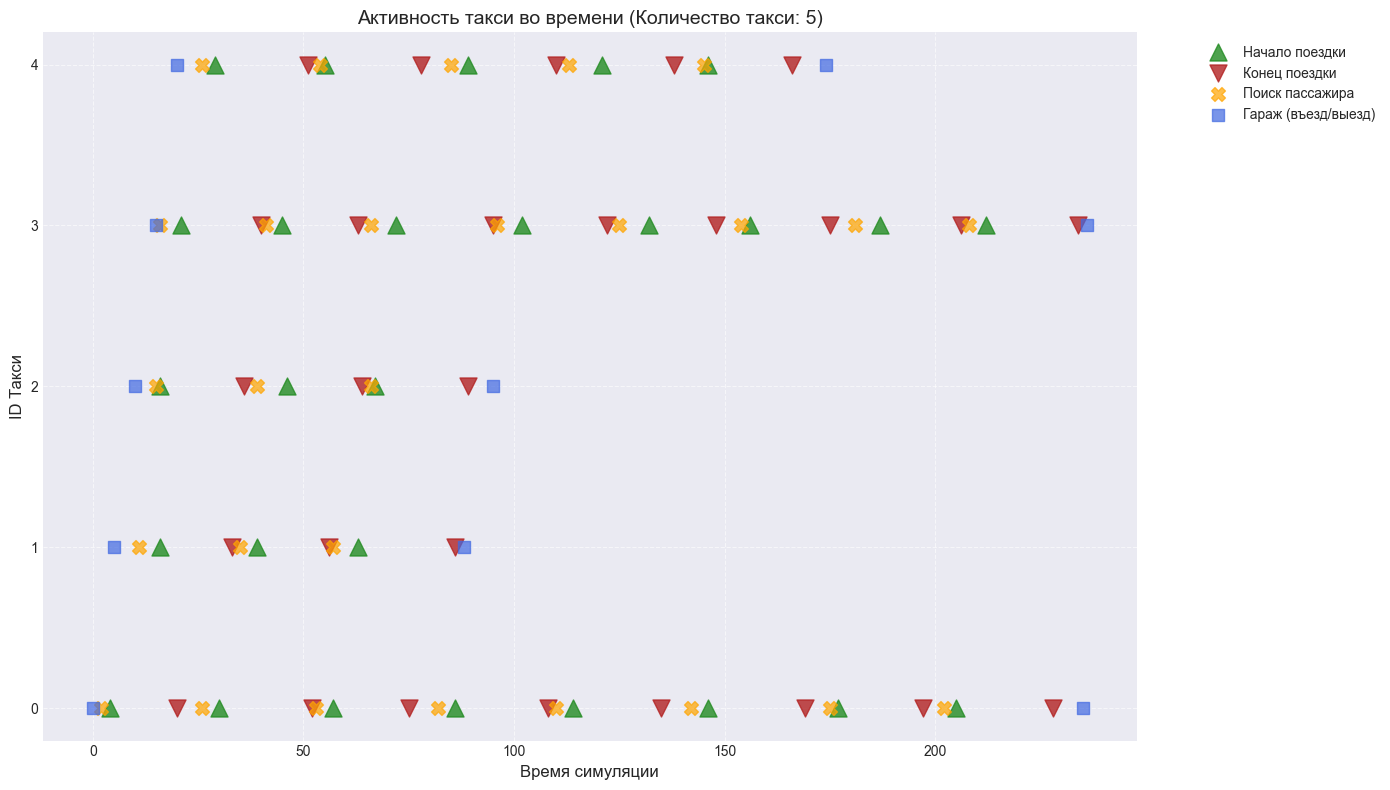

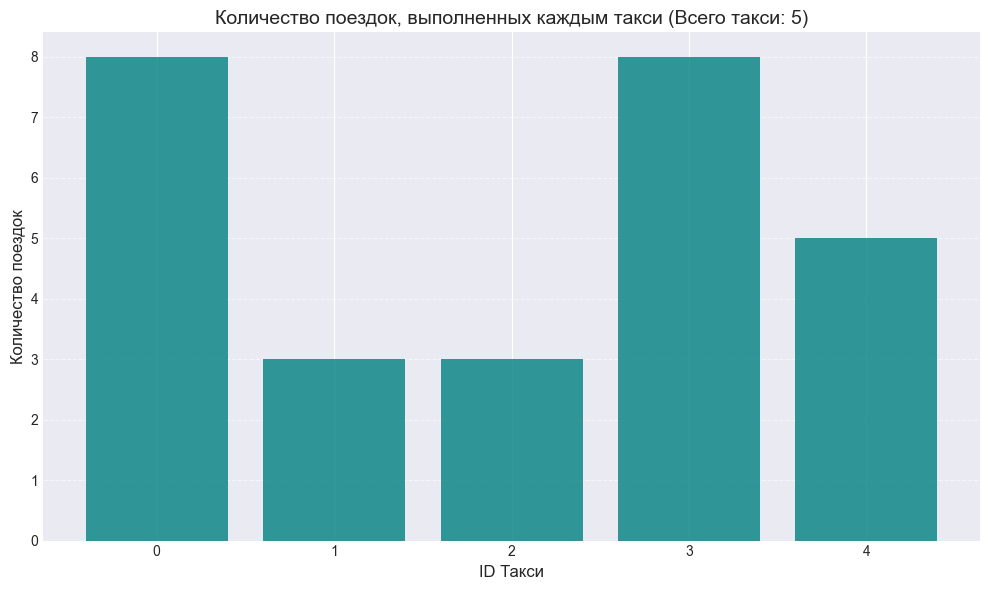

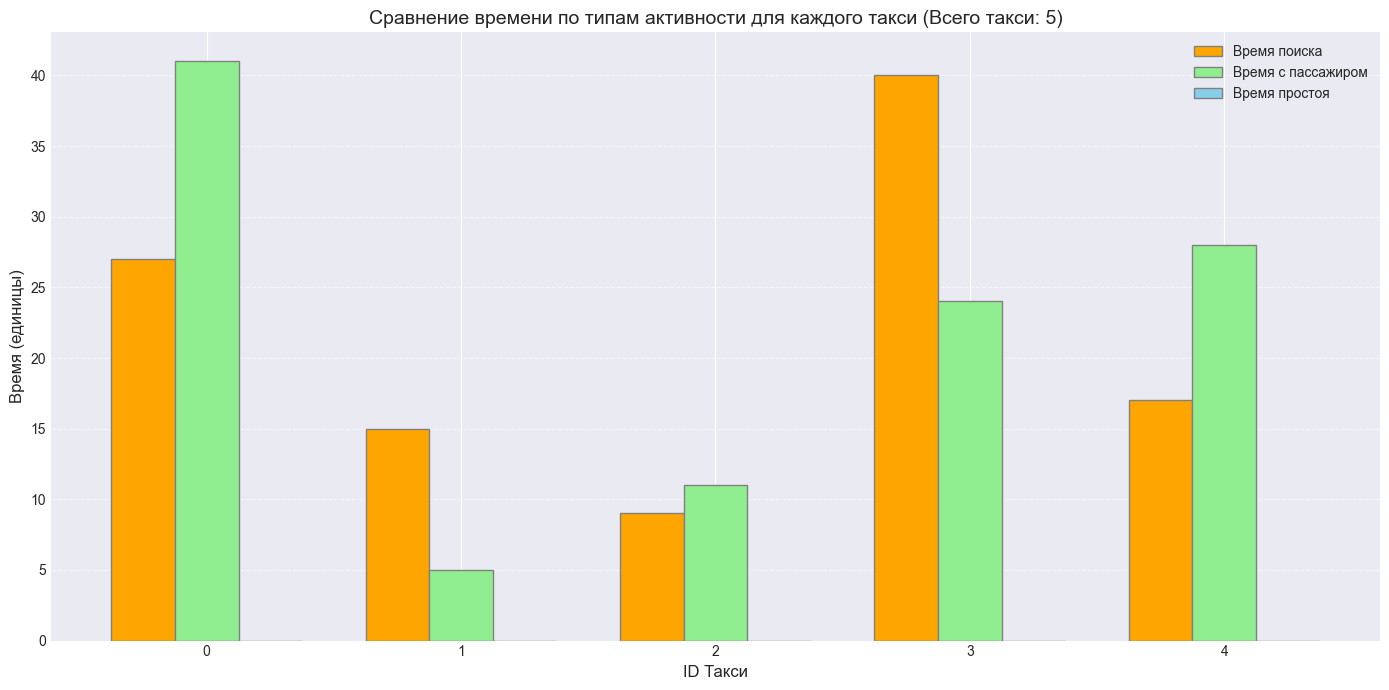


--- Сводная статистика симуляции ---
Общее количество выполненных поездок: 27
Общее время с пассажиром: 109.00
Общее время поиска пассажиров: 108.00
Общее время простоя такси: 0.00
Среднее время одной поездки: 4.04
Среднее время поиска на одно такси: 21.60
-------------------------------------

=== Вариант 2: 7 такси, другое seed ===
Такси 0: поездок=3, время с пассажиром=15.00, время поиска=13.00, время простоя=0.00
Такси 2: поездок=3, время с пассажиром=12.00, время поиска=9.00, время простоя=0.00
Такси 6: поездок=3, время с пассажиром=21.00, время поиска=18.00, время простоя=0.00
Такси 1: поездок=5, время с пассажиром=24.00, время поиска=15.00, время простоя=0.00
Такси 5: поездок=5, время с пассажиром=26.00, время поиска=21.00, время простоя=0.00
Такси 4: поездок=6, время с пассажиром=24.00, время поиска=24.00, время простоя=0.00
Такси 3: поездок=9, время с пассажиром=50.00, время поиска=42.00, время простоя=0.00

--- Лог симуляции ---
***События закончились! Время=296***
0:   0 >>

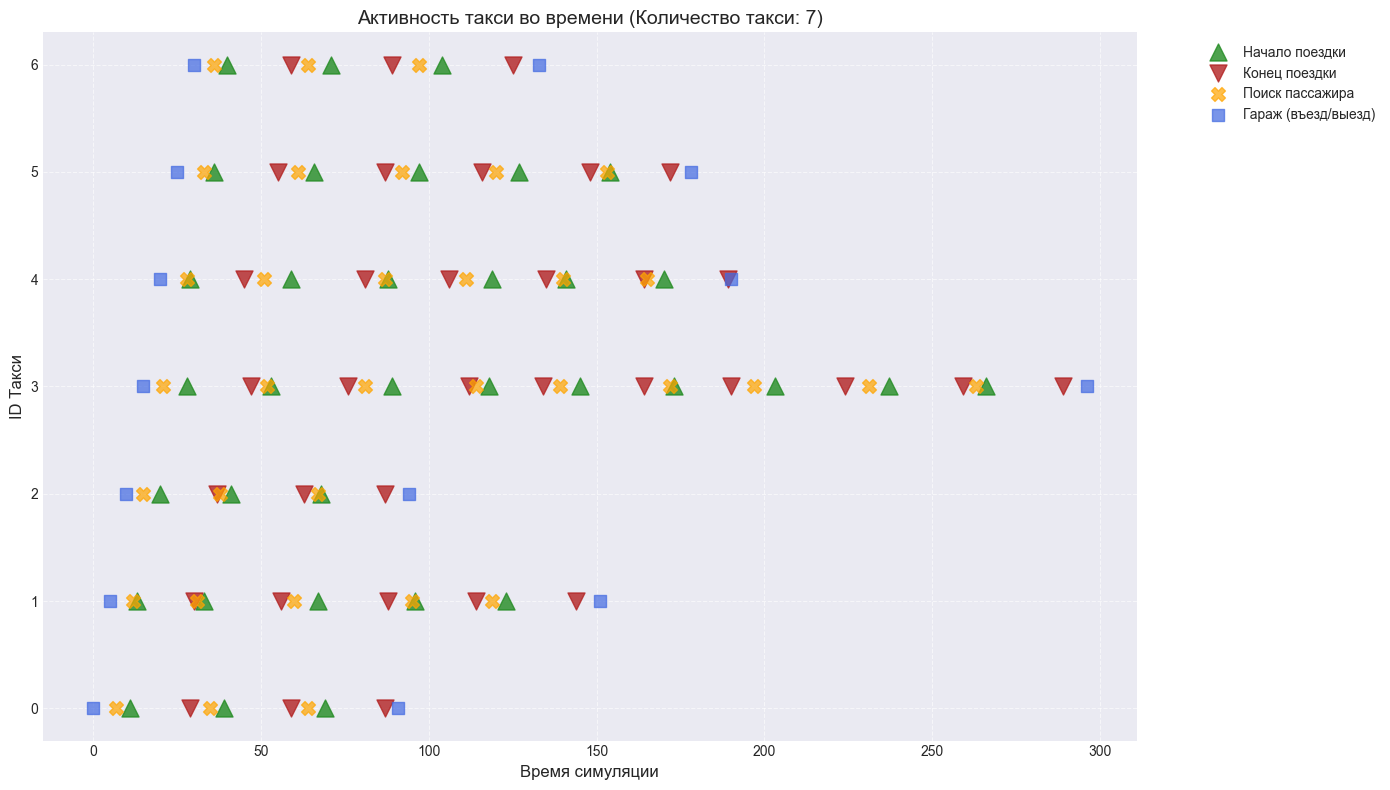

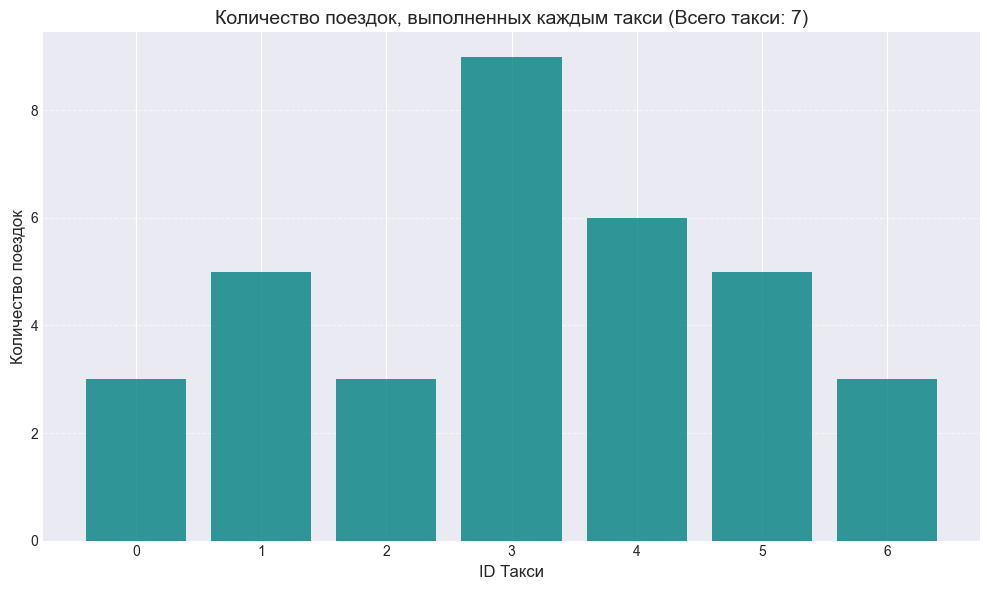

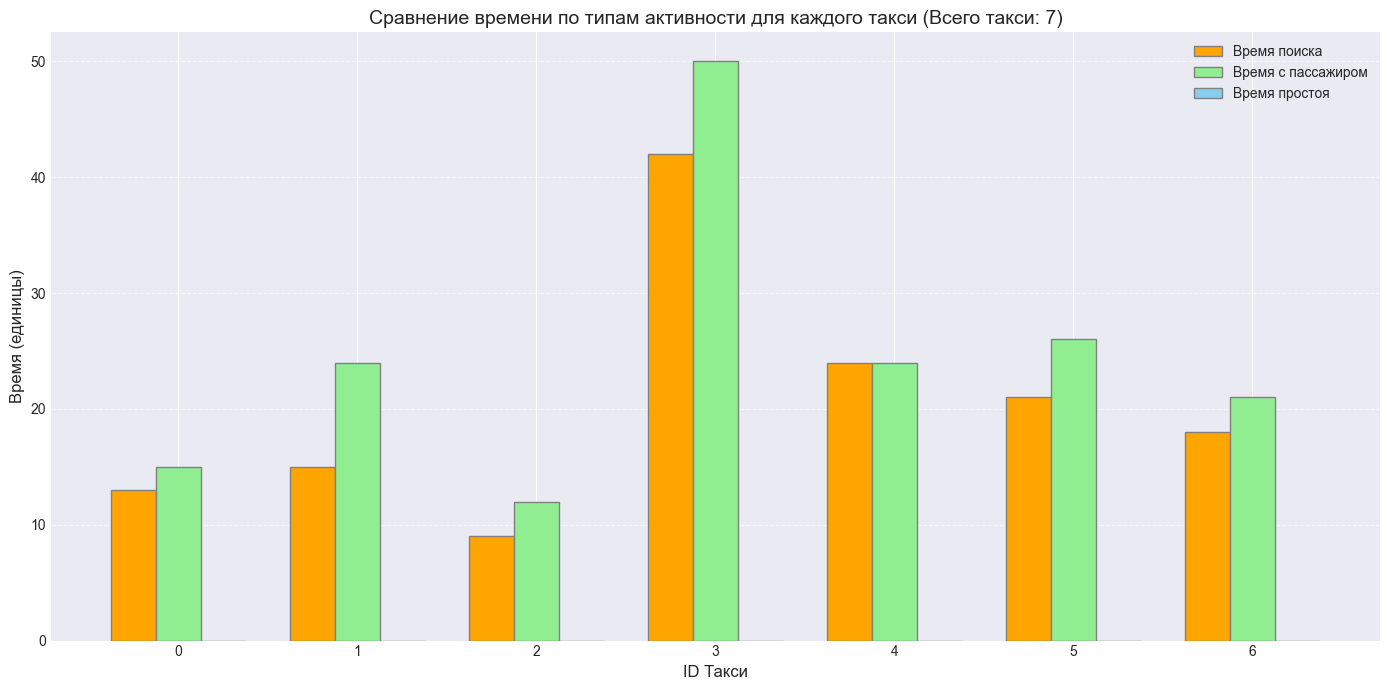


--- Сводная статистика симуляции ---
Общее количество выполненных поездок: 34
Общее время с пассажиром: 172.00
Общее время поиска пассажиров: 142.00
Общее время простоя такси: 0.00
Среднее время одной поездки: 5.06
Среднее время поиска на одно такси: 20.29
-------------------------------------

=== Вариант 3: 9 такси ===
Такси 1: поездок=3, время с пассажиром=15.00, время поиска=9.00, время простоя=0.00
Такси 2: поездок=3, время с пассажиром=14.00, время поиска=7.00, время простоя=0.00
Такси 5: поездок=4, время с пассажиром=19.00, время поиска=23.00, время простоя=0.00
Такси 7: поездок=4, время с пассажиром=14.00, время поиска=25.00, время простоя=0.00
Такси 4: поездок=5, время с пассажиром=18.00, время поиска=24.00, время простоя=0.00
Такси 6: поездок=4, время с пассажиром=14.00, время поиска=25.00, время простоя=0.00
Такси 0: поездок=8, время с пассажиром=40.00, время поиска=44.00, время простоя=0.00
Такси 3: поездок=8, время с пассажиром=31.00, время поиска=38.00, время простоя=0.0

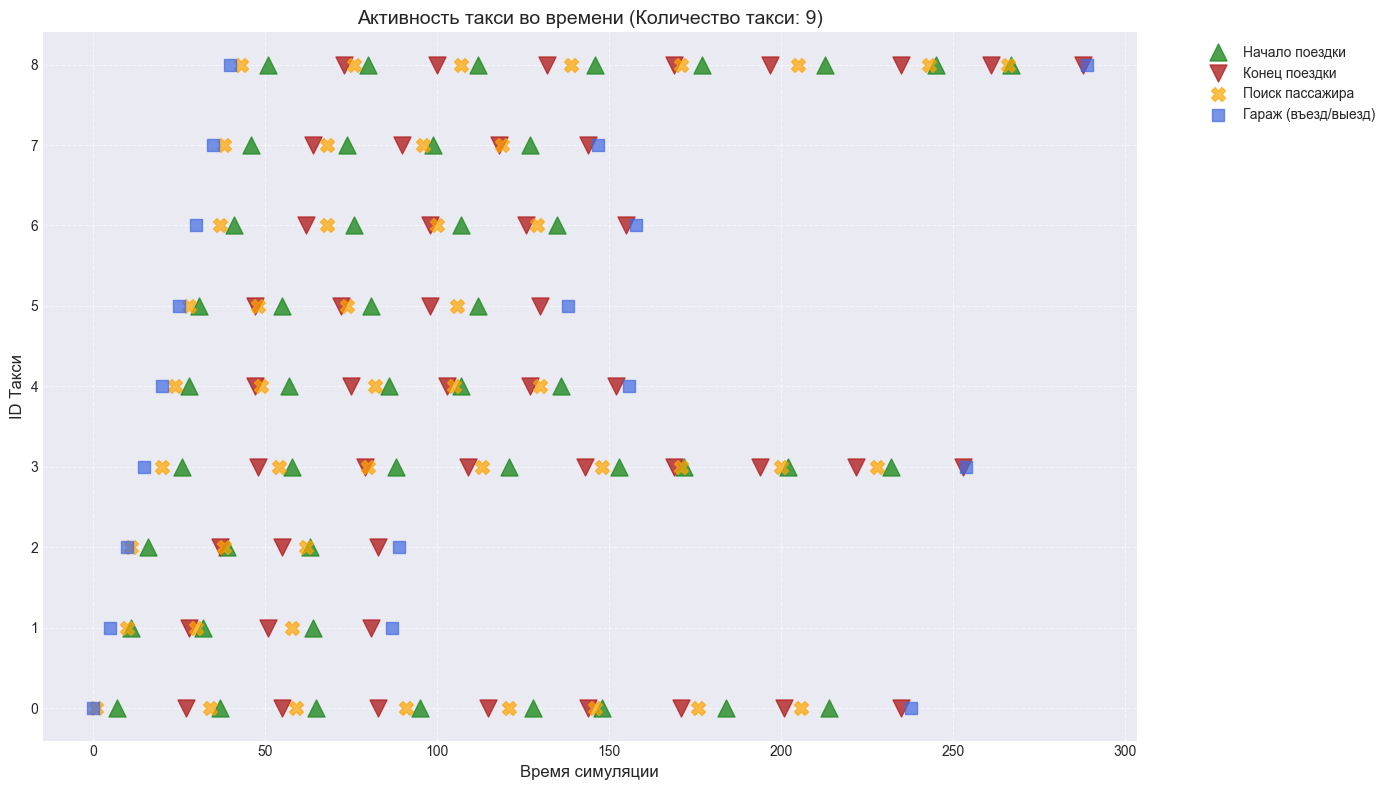

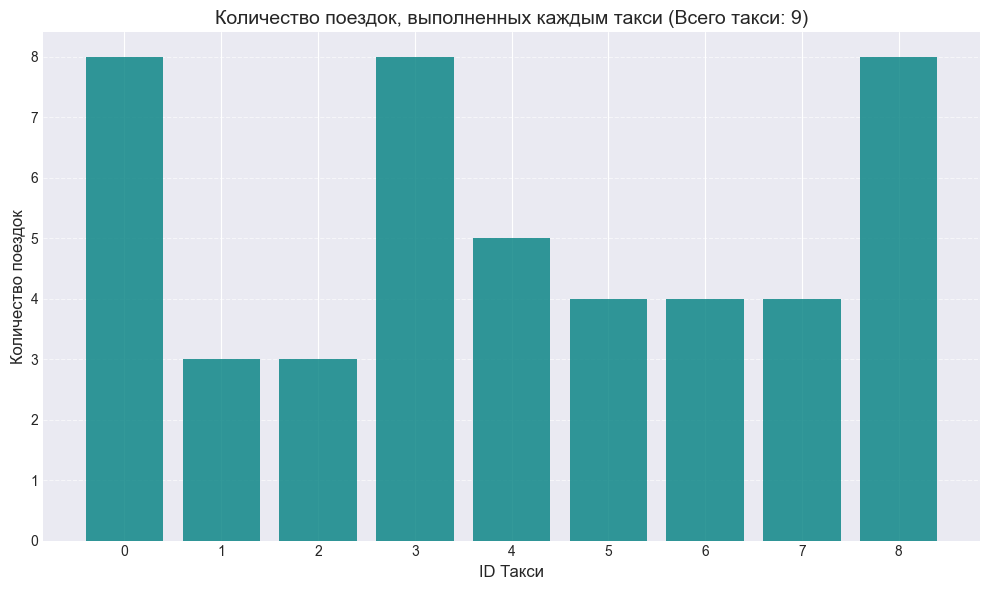

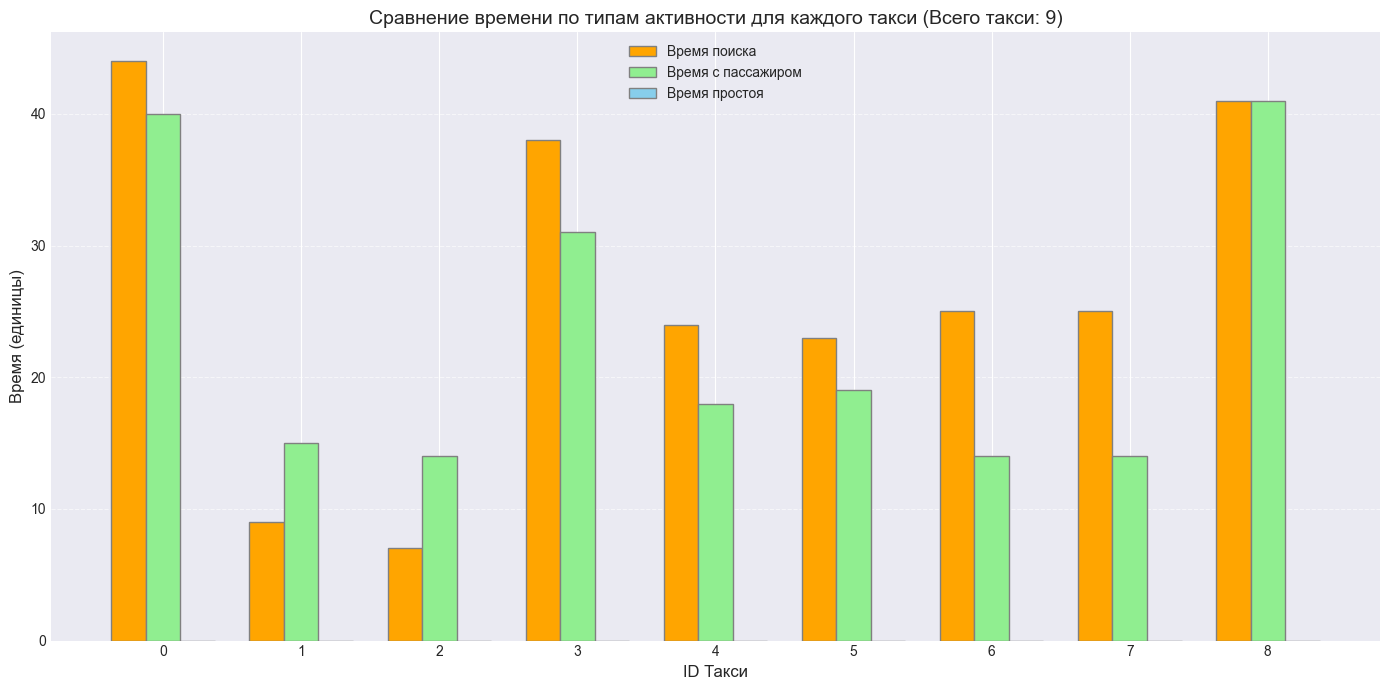


--- Сводная статистика симуляции ---
Общее количество выполненных поездок: 47
Общее время с пассажиром: 206.00
Общее время поиска пассажиров: 236.00
Общее время простоя такси: 0.00
Среднее время одной поездки: 4.38
Среднее время поиска на одно такси: 26.22
-------------------------------------


In [7]:
# Запуск с разными параметрами
print("=== Вариант 1: 5 такси ===")
main(300, 5, 42)

print("\n=== Вариант 2: 7 такси, другое seed ===")
main(300, 7, 123)

print("\n=== Вариант 3: 9 такси ===")
main(300, 9, 42)
